In [238]:
!pip install jupyter ipykernel numpy pandas matplotlib tqdm vector tables scipy

#ipykernel: bridge between jupyter nb and python *essential for running python in jupyter nb
#numpy: python library for working with arrays, for linear algebra, fourier tranform, and matrices
#pandas: allows for handling of data, merging, joining datasets, inserting and deleting columns from DataFrames
#matplotlib: library for creating static, animaed, and interactice visualizations in python, line plots, bar charts, histograms, scatter plots, and 3D vis
#tqdm: provides extensible progress bars for loops and iterables --> visualize progress of time consuming tasks
#vector: python library for 2D and 3D spatial vectors, (even 4D). INTENDED FOR PERFRMING GEOMTRIC CALCS. ON ARRAYS OF VECTORS
#tables: storing and reading large arrays, tables, and nested data structures
#scipy: builds on capabilities of numpy and provides additional functionality

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import pickle
from collections import OrderedDict #helps to remember order of key insertions
import sys
plot_dir = "OmniFold"

In [240]:

# Update the file path to your local file
local_file_path = r"C:\Users\HB\OneDrive\Desktop\OmniFold\files\pseudodata\multifold.h5"

multifold_util = r"C:\Users\HB\OneDrive\Desktop\OmniFold\files\pseudodata\multifold_util.py"

if os.path.isfile(local_file_path):
    print("Skipping download -- data already exists locally.")
else:
    print("File not found at the specified path.")

try:
    sys.path.append(os.path.dirname(multifold_util)) #adds multifold_util to list of directories that python searches for modules
    from multifold_util import *
    import numpy as np
    import pandas as pd
    pd.options.mode.chained_assignment = None
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import os
    import pickle

    if os.path.isfile(multifold_util):
        print("Done!")
    else:
        raise Exception("File does not exist.")

except Exception as e:
    print(f"There was an error: {e}")

Skipping download -- data already exists locally.
Done!


In [241]:
n_events = None #means to use the full dataset

In [242]:
print("Loading the measurement - based on pseudo-data with known underlying distribution (target).")

# This is the high statistics underlying particle level distribution
# The known target in this case. It was generating based on Sherpa 2.2.11 as the Drell-Yan component
target = pd.read_hdf(r"C:\Users\HB\OneDrive\Desktop\OmniFold\files\pseudodata\target.h5", stop = n_events) #allows to read data from HDF5 file

# (Pseudo) measurement of the pseudo-data using the nominal MG5 sample
multifold = pd.read_hdf(r"C:\Users\HB\OneDrive\Desktop\OmniFold\files\pseudodata\multifold.h5", stop = n_events)
# (Pseudo) measurement of the pseudo-data using the alternative Sherpa sample for unfolding
multifold_sherpa = pd.read_hdf(r"C:\Users\HB\OneDrive\Desktop\OmniFold\files\pseudodata\multifold_sherpa.h5", stop = n_events)
multifold_nonDY = pd.read_hdf(r"C:\Users\HB\OneDrive\Desktop\OmniFold\files\pseudodata\multifold_nonDY.h5", stop = n_events)
mc_preds = np.load(r"C:\Users\HB\OneDrive\Desktop\OmniFold\files\pseudodata\mc_preds.npy", allow_pickle=True) #allow pickle to load data from a numpy file

Loading the measurement - based on pseudo-data with known underlying distribution (target).


In [243]:
### Construct masks for track pT cuts to avoid low momentum events
# note that in the pseudodata they are comparing m5 sim to sherpa sim
mask_trackj1 = np.array(multifold['pT_trackj1'] > 5, dtype='bool')
mask_trackj2 = np.array(multifold['pT_trackj2'] > 5, dtype='bool')

mask_sherpa_trackj1 = np.array(multifold_sherpa['pT_trackj1'] > 5, dtype='bool')
mask_sherpa_trackj2 = np.array(multifold_sherpa['pT_trackj2'] > 5, dtype='bool')

mask_nonDY_trackj1 = np.array(multifold_nonDY['pT_trackj1'] > 5, dtype='bool')
mask_nonDY_trackj2 = np.array(multifold_nonDY['pT_trackj2'] > 5, dtype='bool')

mask_target_trackj1 = np.array(target['pT_trackj1'] > 5, dtype='bool')
mask_target_trackj2 = np.array(target['pT_trackj2'] > 5, dtype='bool')

dataframes: spreadsheets with named columns, mixed types, and row indices
    - use when data has named columns you want to access by name

arrays: raw grid of numbers, no column nmes, better for math

Convert data into an array when you need
- ordered data
- index-based access
- iteration using array functions

In [244]:
bins_dict = ibu_bins # defined in demo_functions.py
#bins_dict['Ntracks_trackj1'] = [0.5, 2.0, 5.0] # example of how to modify binning for a given variable

print(f"Loaded bins for {len(bins_dict)} observables:")
for obs, bins in bins_dict.items():
    print("{:>15} with {:2} bins [{:.1f} ... {:.1f}]".format(obs,len(bins),bins[0],bins[-1]))
    # print("  {}, {} bins: {}".format(obs,len(bins),bins))

#only set this to truw when you change binning definitions and change back to false after running the uncertainty cell
Force_recalculate = False

Loaded bins for 26 observables:
          pT_l1 with  7 bins [25.0 ... 800.0]
          pT_l2 with  7 bins [25.0 ... 400.0]
         eta_l1 with 15 bins [-2.5 ... 2.5]
         eta_l2 with 15 bins [-2.5 ... 2.5]
         phi_l1 with 17 bins [-3.1 ... 3.1]
         phi_l2 with 17 bins [-3.1 ... 3.1]
     pT_trackj1 with  7 bins [5.0 ... 1000.0]
     pT_trackj2 with  5 bins [5.0 ... 500.0]
      y_trackj1 with 19 bins [-2.5 ... 2.5]
      y_trackj2 with 11 bins [-2.5 ... 2.5]
    phi_trackj1 with 17 bins [-3.1 ... 3.1]
    phi_trackj2 with 17 bins [-3.1 ... 3.1]
          pT_ll with  6 bins [200.0 ... 1000.0]
           y_ll with 15 bins [-2.5 ... 2.5]
Ntracks_trackj1 with  3 bins [0.5 ... 5.0]
Ntracks_trackj2 with  6 bins [0.5 ... 34.5]
      m_trackj1 with  7 bins [0.0 ... 70.0]
      m_trackj2 with  5 bins [0.0 ... 40.0]
   tau1_trackj1 with  8 bins [0.0 ... 0.9]
   tau1_trackj2 with  6 bins [0.0 ... 0.9]
   tau2_trackj1 with  8 bins [0.0 ... 0.5]
   tau2_trackj2 with  6 bins [0.0 ...

In [245]:
# List of systematic uncertainties, stored as weights in the dataset
#ssystematic uncertainties are systematic biases or gaps in modelling of the detector and theory
event_systs     = [col for col in multifold.keys() if col.startswith("weights_muEff")] + ['weights_pileup']
theory_systs    = [col for col in multifold.keys() if col.startswith("weights_theory")]
track_systs     = [col for col in multifold.keys() if col.startswith("weights_track")]
muon_systs      = [col for col in multifold.keys() if col.startswith("weights_muCal")]

# List of stochastic uncertainty names
#stochastic uncertainties are statistical, random fluctuations
mc_stat_systs   = [col for col in multifold.keys() if col.startswith("weights_bootstrap_mc")]
data_stat_systs = [col for col in multifold.keys() if col.startswith("weights_bootstrap_data")]
ensemble_systs  = [col for col in multifold.keys() if col.startswith("weights_ensemble")]

.keys() method is used to return "dynamic view object" containing all the keys present in the dictionary
col for col in multifold.keys() if col.startswith("") iterates over all column names in multifold and only keeps those starting with ""

In [110]:
uncertainties_filepath = r"C:\Users\HB\OneDrive\Desktop\OmniFold\pseudodata_uncertainties.p"

if os.path.exists(uncertainties_filepath) and not Force_recalculate:
    print("Using pre-calculated uncertainties.") 
    uncertainties = np.load(uncertainties_filepath, allow_pickle=True)
else:
    print("Recalculating uncertainties from scratch.")
    uncertainties = {}

    for i in tqdm(range(24), desc="Unfolded vars"): # number of unfolded observables
        var = list(bins_dict.items())[i][0] #need list to create something indexable
        bins = np.array(list(bins_dict.items())[i][1])
        bin_centers = 0.5 * (bins[1:] + bins[:-1])

        if "trackj1" in var: 
            df = multifold[mask_trackj1]
            df_sherpa = multifold_sherpa[mask_sherpa_trackj1]
            df_nonDY = multifold_nonDY[mask_nonDY_trackj1]
        elif "trackj2" in var:
            df = multifold[mask_trackj2]
            df_sherpa = multifold_sherpa[mask_sherpa_trackj2]
            df_nonDY = multifold_nonDY[mask_nonDY_trackj2]
        else:
            df = multifold
            df_sherpa = multifold_sherpa
            df_nonDY = multifold_nonDY
            
        nom, _ = np.histogram(df[var], bins=bins, weights=df.weights_nominal)    

        final_event          = calculate_uncertainty(df, var, bins, event_systs)
        final_theory         = calculate_uncertainty(df, var, bins, theory_systs)
        final_track          = calculate_uncertainty(df, var, bins, track_systs)
        final_muon           = calculate_uncertainty(df, var, bins, muon_systs)
        final_mc_stat        = calculate_stat_uncertainty(df, var, bins, mc_stat_systs)
        final_data_stat      = calculate_stat_uncertainty(df, var, bins, data_stat_systs)
        final_nn_init        = calculate_stat_uncertainty(df, var, bins, ensemble_systs)/np.sqrt(len(ensemble_systs))
        
        ### Unfolding (DD)
        syst, _ = np.histogram(df[var], bins=bins, weights=df.weights_dd)
        target_dd, _ = np.histogram(df[var], bins=bins, weights=df.target_dd)
        final_unfolding_dd = 100*np.sqrt((syst-target_dd)**2)/target_dd

        ### Unfolding (HV)
        syst, _ = np.histogram(df_sherpa[var], bins=bins, weights=df_sherpa.weights_nominal)
        smoothed_hv_syst_signed = smooth_uncertainty(syst-nom, bin_centers)
        final_unfolding_hv = 100*np.sqrt((smoothed_hv_syst_signed)**2)/nom

        ### Sum these together in quadrature
        final_unfolding = np.sqrt(final_unfolding_hv**2 + final_unfolding_dd**2)

        ### Luminosity 
        syst, _ = np.histogram(df[var], bins=bins, weights=df.weights_lumi)
        final_lumi = 100*np.sqrt((syst-nom)**2)/nom

        ### Top Background 
        syst, _ = np.histogram(df[var], bins=bins, weights=df.weights_topBackground)
        final_top = 100*np.sqrt((syst-nom)**2)/nom

        ### Non-Strong Background
        syst, _ = np.histogram(df_nonDY[var], bins=bins, weights=df_nonDY.weights_nominal)
        final_nonDY = 100*np.sqrt((syst-nom)**2)/nom

        final_exp = np.sqrt(final_lumi**2 + final_muon**2 + final_track**2 + final_event**2)
        uncertainties[var+"_exp"] = final_exp
        uncertainties[var+"_theory"] = final_theory
        uncertainties[var+"_mc_stat"] = np.sqrt(final_mc_stat**2 + final_nn_init**2)
        uncertainties[var+"_data_stat"] = final_data_stat
        uncertainties[var+"_unfolding"] = final_unfolding
        uncertainties[var+"_top"] = final_top
        uncertainties[var+"_nonDY"] = final_nonDY

        total = np.sqrt(
            + final_theory**2 
            + final_exp**2
            + final_mc_stat**2
            + final_data_stat**2
            + final_unfolding**2
            + final_top**2
            + final_nonDY**2
        )
        uncertainties[var+"_total"] = total

        print(f"Saving calculated uncertainties to folder: {uncertainties_filepath}")
        with open(uncertainties_filepath, "wb") as f:
            pickle.dump(uncertainties, f)
        print("Done")


Using pre-calculated uncertainties.


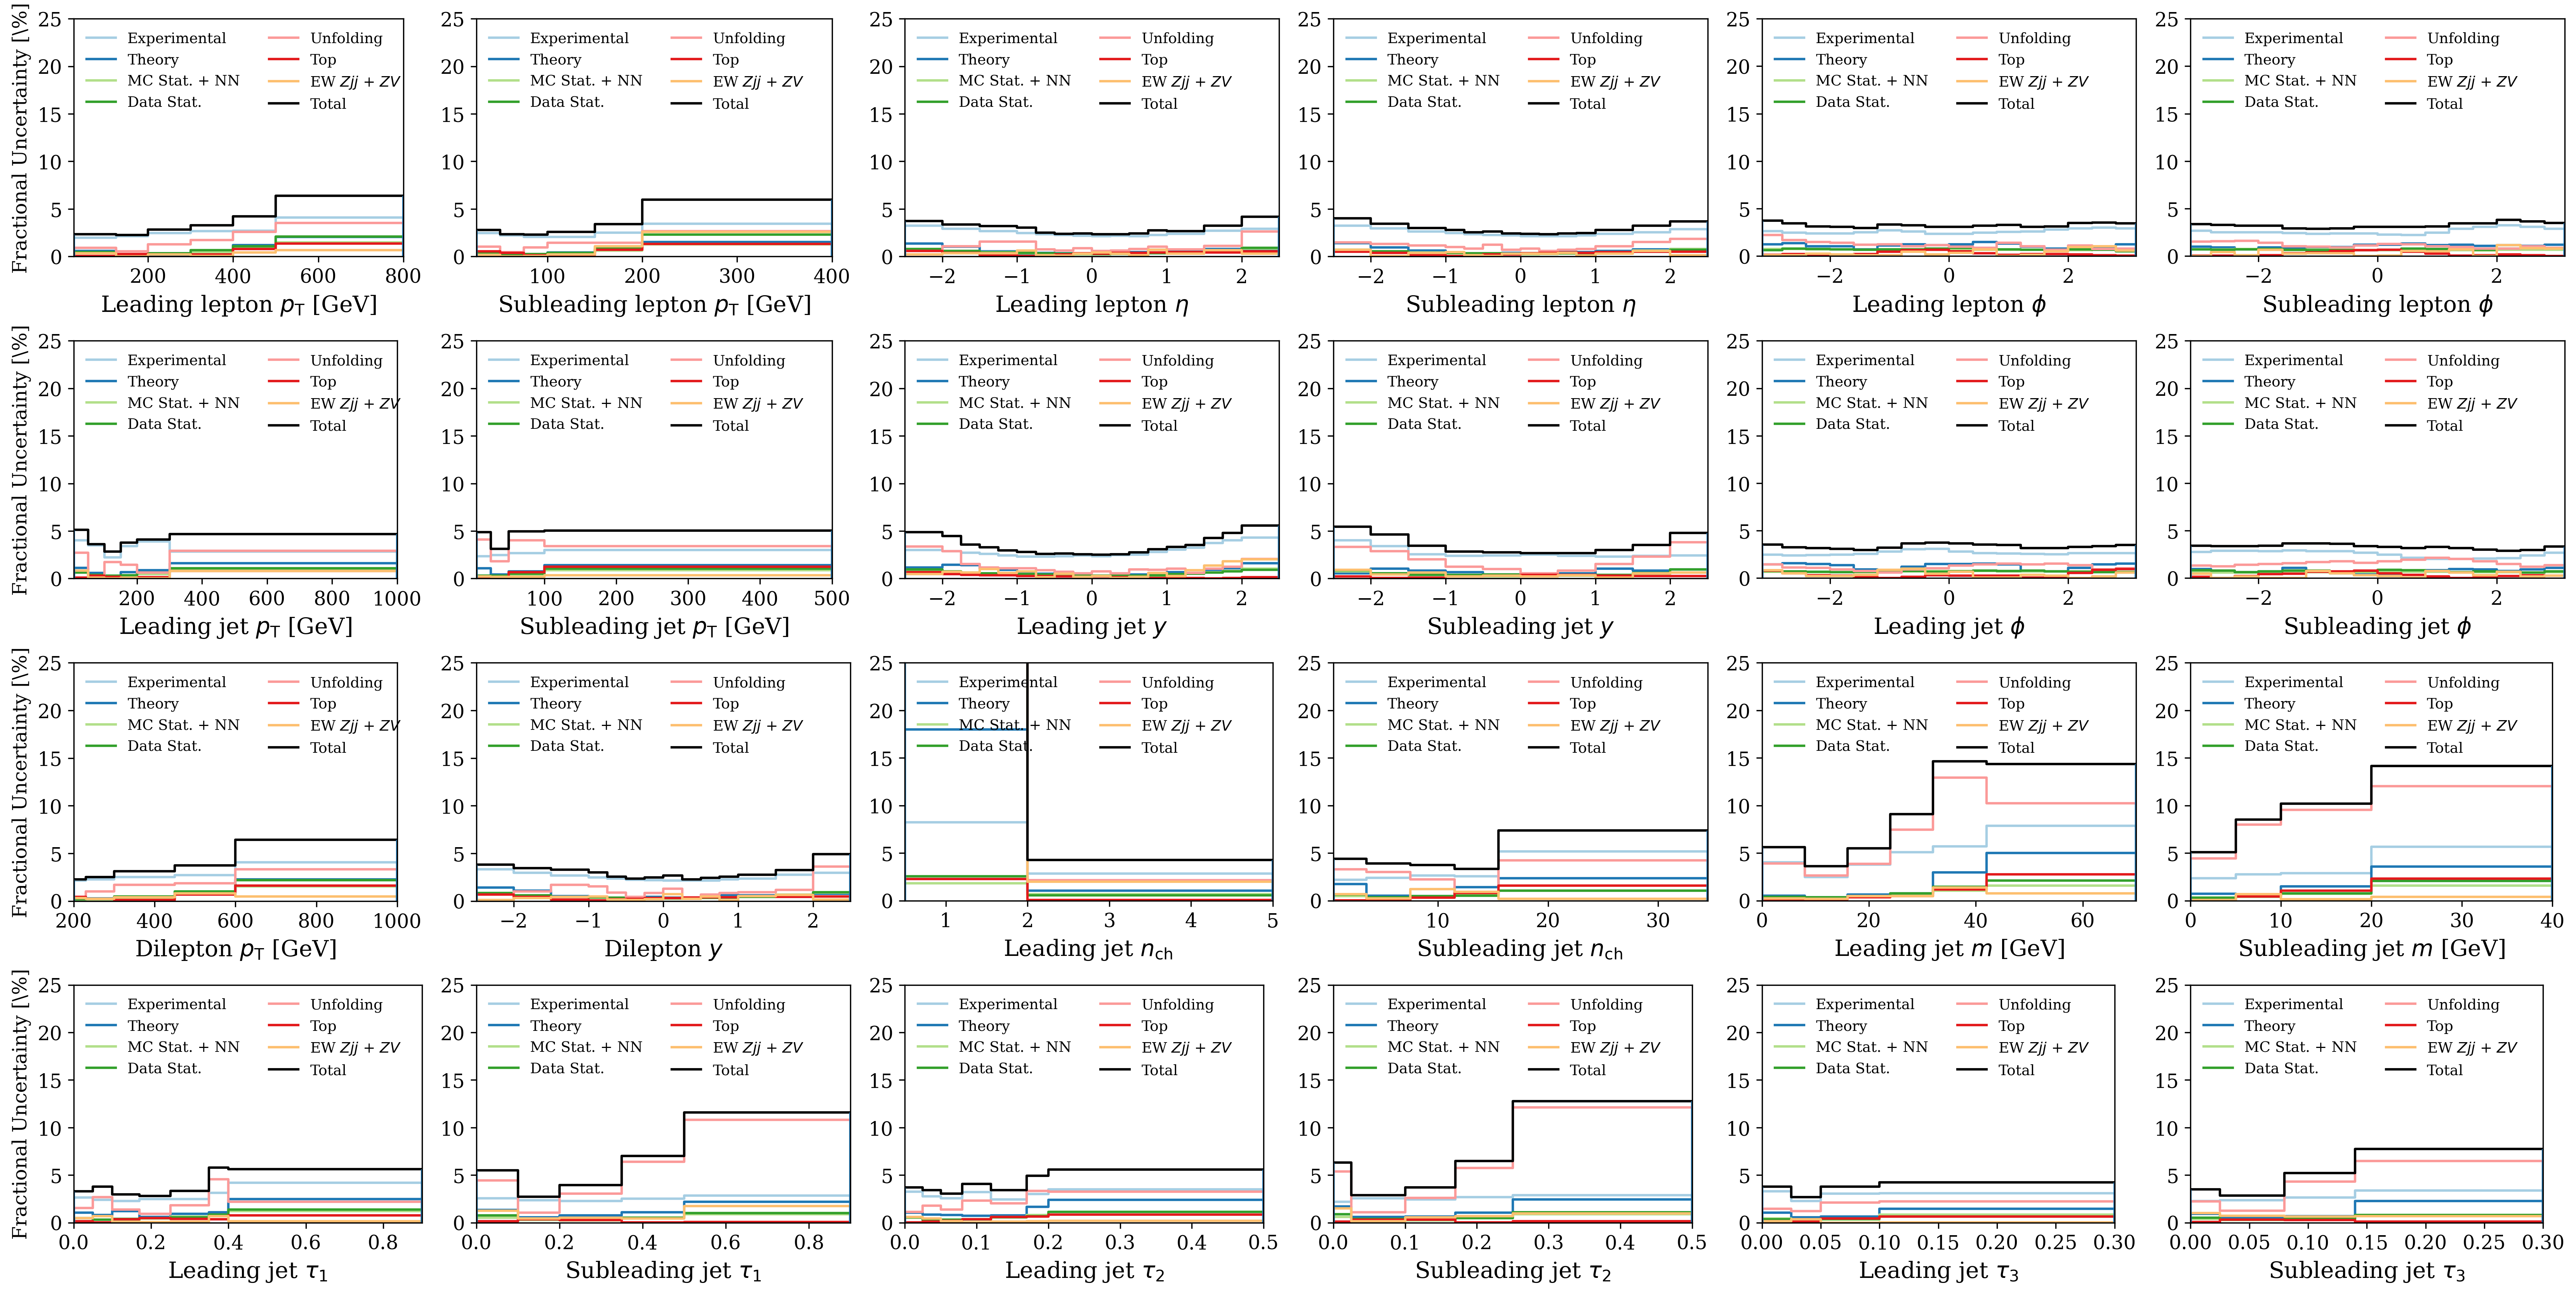

In [16]:
import matplotlib
matplotlib.rcParams['text.usetex'] = False
fig = plt.figure(figsize=(22,11), dpi=300, constrained_layout=True)
subfigs = fig.subfigures(4, 6)

for i, subfig in enumerate(subfigs.flat):
    ax = subfig.subplots(1, 1)
    colors = [plt.cm.Paired(i) for i in range(20)]
    var = list(bins_dict.items())[i][0]
    bins = np.array(list(bins_dict.items())[i][1])

    ax.step(bins, np.concatenate([[uncertainties[var+'_exp'][0]],uncertainties[var+'_exp']]),              label = "Experimental",       color=colors[0],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_theory'][0]],uncertainties[var+'_theory']]),        label = "Theory",             color=colors[1],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_mc_stat'][0]],uncertainties[var+'_mc_stat']]),      label = "MC Stat. + NN",      color=colors[2],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_data_stat'][0]],uncertainties[var+'_data_stat']]),  label = "Data Stat.",         color=colors[3],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_unfolding'][0]],uncertainties[var+'_unfolding']]),  label = "Unfolding",          color=colors[4]     )
    ax.step(bins, np.concatenate([[uncertainties[var+'_top'][0]],uncertainties[var+'_top']]),              label = "Top",                color=colors[5],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_nonDY'][0]],uncertainties[var+'_nonDY']]),          label = r"EW $Zjj$ + $ZV$",   color=colors[6],    )
    ax.step(bins, np.concatenate([[uncertainties[var+'_total'][0]],uncertainties[var+'_total']]),          label = "Total",              color='black',      )

    ### draw lines at the beginning and end of the first and last bins, for plotting purposes
    label_list = ['exp', 'theory', 'mc_stat', 'data_stat', 'unfolding', 'top', 'nonDY', 'total']
    for label in label_list:
        plt.vlines(x=bins[0], ymin=0, ymax=uncertainties[var+'_'+label][0])
        plt.vlines(x=bins[-1], ymin=0, ymax=uncertainties[var+'_'+label][-1])

    ax.xaxis.set_tick_params(labelsize=12)
    ax.yaxis.set_tick_params(labelsize=12)
    if i % 6 == 0: ax.set_ylabel(r"Fractional Uncertainty [\%]", fontsize=12)
    ax.legend(fontsize=9, loc='upper left', ncol=2, frameon=False)
    ax.set_xlim([bins[0], bins[-1]])
    ax.set_ylim([0, 25])
    ax.set_xlabel(plot_labels[var], fontsize=14);

plt.savefig(r"C:\Users\HB\OneDrive\Desktop\OmniFold\total_systs")

Plots:  58%|███████████████████████████████████████████▊                               | 14/24 [00:10<00:07,  1.33it/s]


ValueError: operands could not be broadcast together with shapes (6,) (2,) 

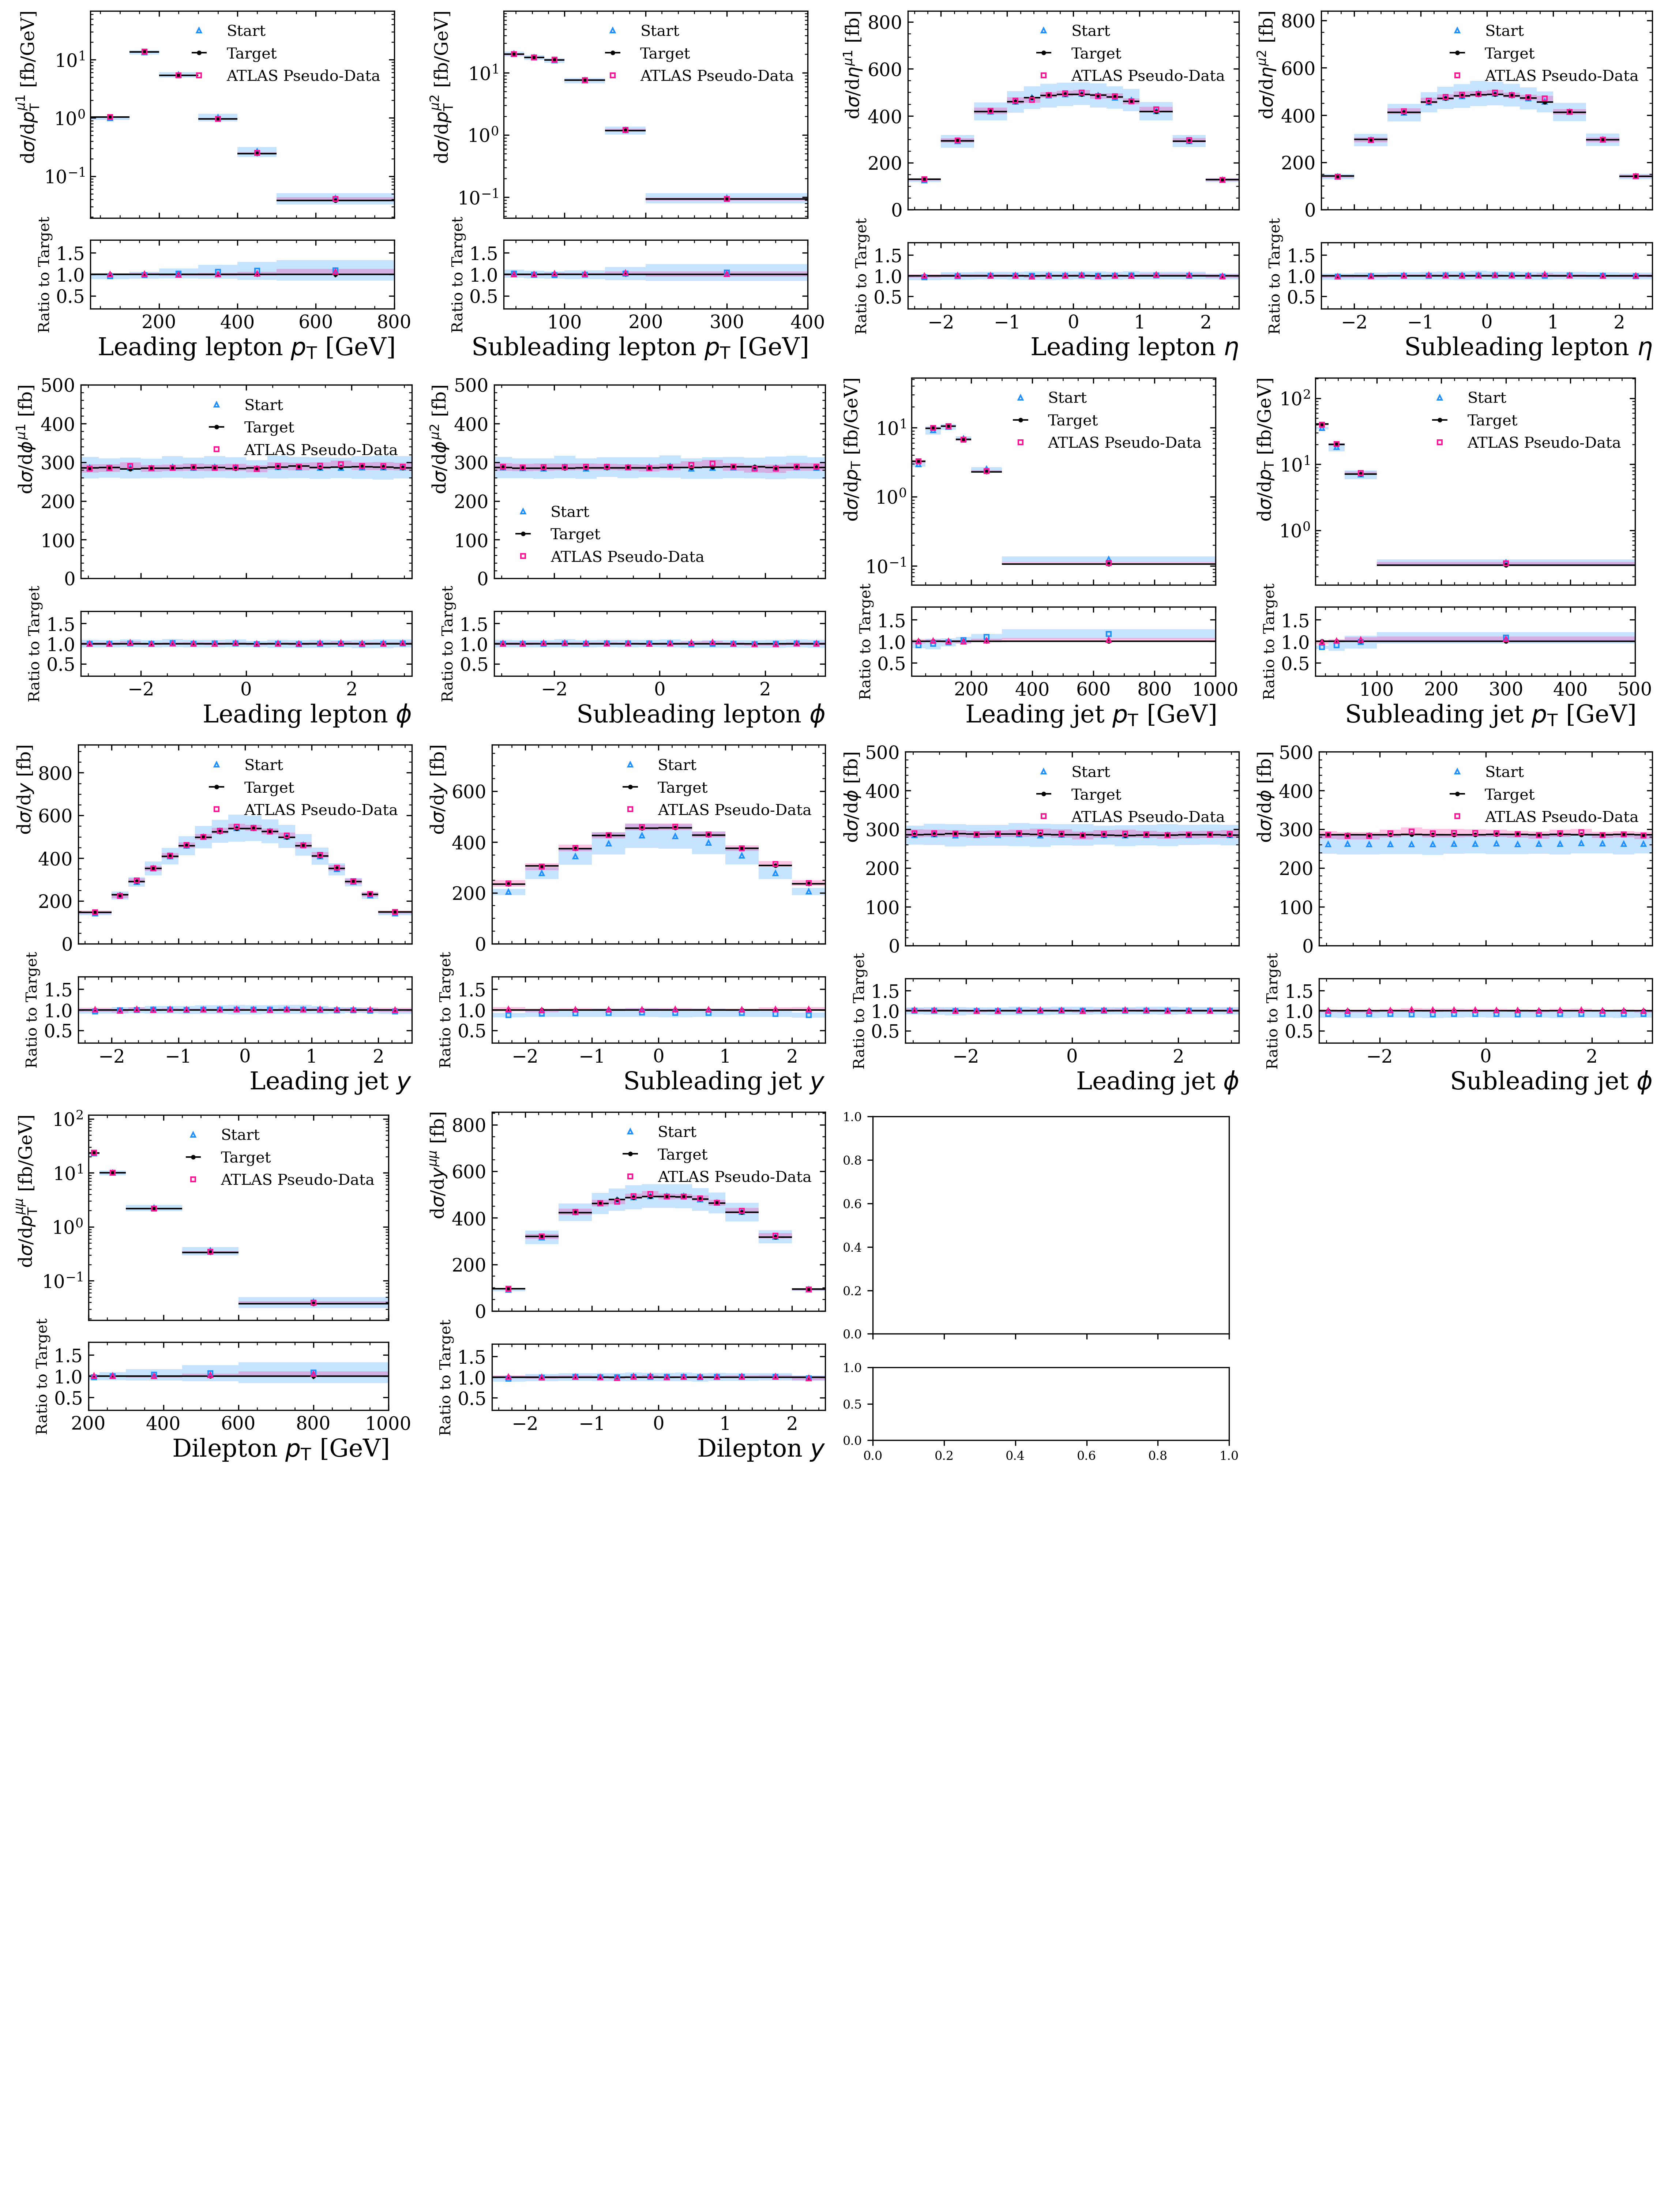

In [117]:
fig = plt.figure(figsize=(15, 20), dpi=300, constrained_layout=True)
subfigs = fig.subfigures(6, 4)

for i, subfig in enumerate(tqdm(subfigs.flat, desc="Plots")):  
    axs = subfig.subplots(2, 1, sharex=True, sharey=False, gridspec_kw={'height_ratios': [3, 1]})
    
    var = list(bins_dict.items())[i][0]
    bins = np.array(list(bins_dict.items())[i][1])
    
    # Calculate bin centers and widths properly inside the loop
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_widths = bins[1:] - bins[:-1]
    
    if "trackj1" in var: 
        df = multifold[mask_trackj1]
    elif "trackj2" in var:
        df = multifold[mask_trackj2]
    else:
        df = multifold    
    
    ### 1. Starting distribution
    counts = mc_preds[i]['mgfxfx_counts']
    start_density = counts / lumi / bin_widths
    start_error = mc_preds[i]['mgfxfx_err'] / mc_preds[i]['mgfxfx_counts']
    _ = make_error_boxes(axs[0], bin_centers, start_density, np.vstack([bin_widths/2, bin_widths/2]), np.vstack([start_density*start_error, start_density*start_error]), facecolor='dodgerblue', alpha=0.25, marker="^", label='Start')
    
    ### 2. Target distribution
    target_density, _, _ = axs[0].hist(target[var], bins=bins, density=True, weights=target.weight_mc, color='k', alpha=0)
    target_density *= np.sum(target.weight_mc)
    axs[0].errorbar(bin_centers, target_density, xerr=bin_widths/2, yerr=None, marker=".", linestyle="None", color="k", alpha=1, ecolor='k', label="Target", markersize=4, linewidth=1)

    ### 3. MultiFold distribution
    multifold_density, _, _ = axs[0].hist(multifold[var], weights=multifold.weights_nominal, bins=bins, histtype='step', color='black', linewidth=2, density=True, alpha=0)
    multifold_density *= np.sum(multifold.weights_nominal)
    _ = make_error_boxes(axs[0], bin_centers, multifold_density, np.vstack([bin_widths/2, bin_widths/2]), np.vstack([multifold_density*uncertainties[var+"_total"]/100, multifold_density*uncertainties[var+"_total"]/100]), facecolor='deeppink', alpha=0.25, marker="s", label='ATLAS Pseudo-Data')

    ### Main Plot (axs[0]) Styling
    axs[0].minorticks_on()
    axs[0].xaxis.set_tick_params(labelsize=12, which='both', direction='in', top=True)
    axs[0].yaxis.set_tick_params(labelsize=12, which='both', direction='in', right=True)
    axs[0].set_ylabel(labels[var], fontsize=12, labelpad=2, loc='top')
    axs[0].set_ylim([0, 1.7 * max(max(target_density), max(multifold_density))])
    
    ### Log vs Linear Scale constraints
    if 'phi' not in var and 'eta' not in var and 'y' not in var:
        axs[0].set_yscale('log')
        axs[0].set_ylim([0.5 * min(min(target_density), min(multifold_density)), 5 * max(max(target_density), max(multifold_density))])
    elif 'phi' in var:
        axs[0].set_ylim(0, 500)
    
    axs[0].legend(fontsize=10, frameon=False, loc='best')

    axs[1].errorbar(bin_centers, np.ones(len(bin_centers)), xerr=bin_widths/2, yerr=uncertainties[var+"_total"]/100, marker=".", linestyle="None", color="k", alpha=1,  ecolor='k', label="ATLAS Pseudo-Data", markersize=4, linewidth=1)
    _ = make_error_boxes(axs[1], bin_centers, start_density/target_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([(start_density/target_density)*start_error, (start_density/target_density)*start_error]), facecolor='dodgerblue', alpha=0.25, marker="s", label=r'Start')
    _ = make_error_boxes(axs[1], bin_centers, multifold_density/target_density, np.vstack([bin_widths/2,bin_widths/2]), np.vstack([(multifold_density/target_density)*uncertainties[var+"_total"]/100, (multifold_density/target_density)*uncertainties[var+"_total"]/100]), facecolor='deeppink', alpha=0.25, marker="^", label=r'MG5+Py8 + $\mathbf{X}$')
    axs[1].set_xlim(bins[0], bins[-1])
    axs[1].set_ylim([0.2,1.8])
    axs[1].xaxis.set_tick_params(labelsize=12, which='both', direction='in', top=True)
    axs[1].yaxis.set_tick_params(labelsize=12, which='both', direction='in', right=True)
    axs[1].set_ylabel('Ratio to Target', fontsize=10, labelpad=2, loc='center')
    axs[1].set_xlabel(plot_labels[var], fontsize=16, labelpad=2, loc='right');
    
# Save the final consolidated multi-panel figure
plt.savefig(r"C:\Users\HB\OneDrive\Desktop\OmniFold\nominal_diff_xsec.pdf")

In [246]:
ibu_bins = OrderedDict()
ibu_bins["pT_l1"] = [25.0, 125.0, 200.0, 300.0, 400.0, 500.0, 800.0]
ibu_bins["pT_l2"] = [25.0, 50.0, 75.0, 100.0, 150.0, 200.0, 400.0]
ibu_bins["eta_l1"] = [-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5]
ibu_bins["eta_l2"] = [-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5]
ibu_bins["phi_l1"] = [-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)]
ibu_bins["phi_l2"] = [-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)]
ibu_bins["pT_trackj1"] = [5.0, 50.0, 100.0, 150.0, 200.0, 300.0, 1000.0]
ibu_bins["pT_trackj2"] = [5.0, 25.0, 50.0, 100.0, 500.0]
ibu_bins["y_trackj1"] = [-2.5, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5]
ibu_bins["y_trackj2"] = [-2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
ibu_bins["phi_trackj1"] = [-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)]
ibu_bins["phi_trackj2"] = [-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)]
ibu_bins["pT_ll"] = [200.0, 230.0, 300.0, 450.0, 600.0, 1000.0]
ibu_bins["y_ll"] = [-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5]
ibu_bins["Ntracks_trackj1"] = [0.5, 6.5, 10.5, 14.5, 19.5, 25.5, 39.5]
ibu_bins["Ntracks_trackj2"] = [0.5, 3.5, 7.5, 11.5, 15.5, 34.5]
ibu_bins["m_trackj1"] = [0.0, 8.0, 16.0, 24.0, 32.0, 42.0, 70.0]
ibu_bins["m_trackj2"] = [0.0, 5.0, 10.0, 20.0, 40.0] 
ibu_bins["tau1_trackj1"] = [0.0, 0.05, 0.1, 0.17, 0.25, 0.35, 0.4, 0.9]
ibu_bins["tau1_trackj2"] = [0.0, 0.1, 0.2, 0.35, 0.5, 0.9]
ibu_bins["tau2_trackj1"] = [0.0, 0.025, 0.05, 0.08, 0.12, 0.17, 0.2, 0.5]
ibu_bins["tau2_trackj2"] = [0.0, 0.025, 0.1, 0.17, 0.25, 0.5]
ibu_bins["tau3_trackj1"] = [0.0, 0.025, 0.05, 0.1, 0.3]
ibu_bins["tau3_trackj2"] = [0.0, 0.025, 0.08, 0.14, 0.3]

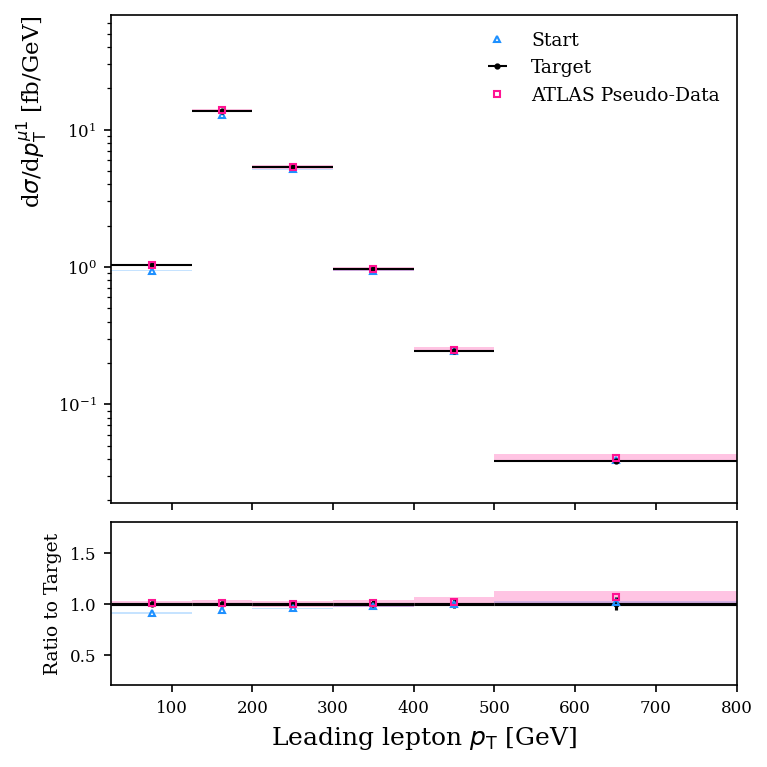

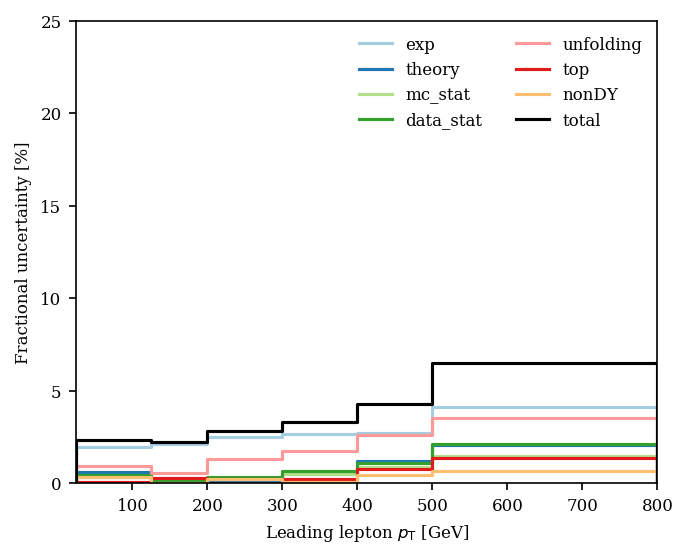

In [256]:
#SAVING THIS CODE HERE IN CASE

main_path = r"C:\Users\HB\OneDrive\Desktop\OmniFold\files\pseudodata"


#Add statement that notifies when a bin has less than 5000 events, statistical uncertainty should be under 15%
#change from matplotlib code to np code
### Plot Ntracks_trackj1 with custom bins using weight_mc (no mc_preds needed)
uncertainties = {
    "exp": final_exp,
    "theory": final_theory,
    "mc_stat": np.sqrt(final_mc_stat**2 + final_nn_init**2),
    "data_stat": final_data_stat,
    "unfolding": final_unfolding,
    "top": final_top,
    "nonDY": final_nonDY_unc,
}

uncertainties["total"] = np.sqrt(
    uncertainties["exp"]**2
    + uncertainties["theory"]**2
    + uncertainties["mc_stat"]**2
    + uncertainties["data_stat"]**2
    + uncertainties["unfolding"]**2
    + uncertainties["top"]**2
    + uncertainties["nonDY"]**2
)

#adding in quadrature accounts for the fact that each source of uncertainy is an independent random error, that don't all propagate in the same direction

def custom_binning(var, binslist):
    lumi = 138.96
    bins = np.array(binslist)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_widths  = np.diff(bins)

    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(5, 5), dpi=150,
                            gridspec_kw={'height_ratios': [3, 1]}, constrained_layout=True)
    
    if "trackj1" in var:
        df       = multifold[mask_trackj1]
        df_sherpa = multifold_sherpa[mask_sherpa_trackj1]
        df_nonDY  = multifold_nonDY[mask_nonDY_trackj1]
    elif "trackj2" in var:
        df        = multifold[mask_trackj2]
        df_sherpa = multifold_sherpa[mask_sherpa_trackj2]
        df_nonDY  = multifold_nonDY[mask_nonDY_trackj2]
    else:
        df        = multifold
        df_sherpa = multifold_sherpa
        df_nonDY  = multifold_nonDY

    nom, _ = np.histogram(df[var], bins=bins, weights=df.weights_nominal) #np.histogram returns counts and bin edges, so use _ because we defined bin_edges already
    final_event     = calculate_uncertainty(df, var, bins, event_systs)
    final_theory    = calculate_uncertainty(df, var, bins, theory_systs)
    final_track     = calculate_uncertainty(df, var, bins, track_systs)
    final_muon      = calculate_uncertainty(df, var, bins, muon_systs)
    final_mc_stat   = calculate_stat_uncertainty(df, var, bins, mc_stat_systs)
    final_data_stat = calculate_stat_uncertainty(df, var, bins, data_stat_systs)
    final_nn_init   = calculate_stat_uncertainty(df, var, bins, ensemble_systs) / np.sqrt(len(ensemble_systs))


    #weights_nominal are final omnifold weights after unfolding procedure --> estimate of particle-level distribution
    #weights_dd are variations of those weights  to estimate unfolding uncertainty
    #final_nn_init is uncertainty coming from nn initialization (differing results due to differing random seeds)
    #nom, syst, and target are all histograms using different weights


    
    syst, _      = np.histogram(df[var], bins=bins, weights=df.weights_dd)
    target_dd, _ = np.histogram(df[var], bins=bins, weights=df.target_dd)
    final_unfolding_dd = 100 * np.sqrt((syst - target_dd)**2) / target_dd
    
    syst, _  = np.histogram(df_sherpa[var], bins=bins, weights=df_sherpa.weights_nominal)
    smoothed = smooth_uncertainty(syst - nom, bin_centers)
    final_unfolding_hv = 100 * np.sqrt(smoothed**2) / nom
    final_unfolding    = np.sqrt(final_unfolding_hv**2 + final_unfolding_dd**2)
    
    syst, _ = np.histogram(df[var], bins=bins, weights=df.weights_lumi)
    final_lumi = 100 * np.sqrt((syst - nom)**2) / nom
    syst, _ = np.histogram(df[var], bins=bins, weights=df.weights_topBackground)
    final_top = 100 * np.sqrt((syst - nom)**2) / nom
    syst, _ = np.histogram(df_nonDY[var], bins=bins, weights=df_nonDY.weights_nominal)
    final_nonDY_unc = 100 * np.sqrt((syst - nom)**2) / nom
    
    final_exp = np.sqrt(final_lumi**2 + final_muon**2 + final_track**2 + final_event**2)
    total_unc = np.sqrt(final_theory**2 + final_exp**2 + final_mc_stat**2 +
                        final_data_stat**2 + final_unfolding**2 + final_top**2 + final_nonDY_unc**2)
        
    
        
    # --- Starting distribution: DY + non-DY, exact equivalent of mc_preds at any binning ---
    dy_counts,       _ = np.histogram(df[var],       bins=bins, weights=df.weight_mc)
    nonDY_counts,    _ = np.histogram(df_nonDY[var], bins=bins, weights=df_nonDY.weight_mc)
    dy_counts_sq,    _ = np.histogram(df[var],       bins=bins, weights=df.weight_mc**2)
    nonDY_counts_sq, _ = np.histogram(df_nonDY[var], bins=bins, weights=df_nonDY.weight_mc**2)
    total_counts    = dy_counts #+ nonDY_counts
    total_counts_sq = dy_counts_sq #+ nonDY_counts_sq
    start_density = total_counts / bin_widths
    start_error   = np.sqrt(total_counts_sq) / total_counts  # relative Poisson error

    _ = make_error_boxes(axs[0], bin_centers, start_density,
                         np.vstack([bin_widths/2, bin_widths/2]),
                         np.vstack([start_density*start_error, start_density*start_error]),
                         facecolor='dodgerblue', alpha=0.25, marker="^", label='Start')
    
    
    ###Target density
    
    target_counts, _ = np.histogram(target[var], bins = bins, weights = target.weight_mc)
    target_density = target_counts / bin_widths
    axs[0].errorbar(bin_centers, target_density, xerr=bin_widths/2, yerr=None, marker=".",
                   linestyle="None", color="k", alpha = 1, ecolor= "k", label="Target", markersize=4, linewidth=1)

   

    multifold_counts, _ = np.histogram(multifold[var], bins=bins, weights=multifold.weights_nominal)
    multifold_density = multifold_counts / bin_widths

    
    _ = make_error_boxes(axs[0], bin_centers, multifold_density,
                         np.vstack([bin_widths/2, bin_widths/2]),
                         np.vstack([multifold_density*total_unc/100, multifold_density*total_unc/100]),
                         facecolor='deeppink', alpha=0.25, marker="s", label='ATLAS Pseudo-Data')
    
    if 'phi' not in var and 'eta' not in var and 'y' not in var:
        axs[0].set_yscale('log')
        axs[0].set_ylim([0.5*min(min(target_density), min(multifold_density)), 5 * max(max(target_density), max(multifold_density))])
    axs[0].set_ylabel(labels[var], fontsize=11, loc='top')
    axs[0].legend(fontsize=9, frameon=False)
    
    axs[1].errorbar(bin_centers, np.ones(len(bin_centers)), xerr=bin_widths/2,
                    yerr=total_unc/100, marker=".", linestyle="None", color="k", markersize=4)
    _ = make_error_boxes(axs[1], bin_centers, start_density/target_density,
                         np.vstack([bin_widths/2, bin_widths/2]),
                         np.vstack([start_density/target_density*start_error]*2),
                         facecolor='dodgerblue', alpha=0.25, marker="^", label='Start')
    _ = make_error_boxes(axs[1], bin_centers, multifold_density/target_density,
                         np.vstack([bin_widths/2, bin_widths/2]),
                         np.vstack([multifold_density/target_density*total_unc/100]*2),
                         facecolor='deeppink', alpha=0.25, marker="s", label='ATLAS Pseudo-Data')
    axs[1].set_xlim(bins[0], bins[-1])
    axs[1].set_ylim([0.2, 1.8])
    axs[1].set_ylabel('Ratio to Target', fontsize=9)
    axs[1].set_xlabel(plot_labels[var], fontsize=12)

    plt.savefig(os.path.join(main_path, f"custom_binning_{var}"))
    plt.show()

    uncertainties = {
    "exp": final_exp,
    "theory": final_theory,
    "mc_stat": np.sqrt(final_mc_stat**2 + final_nn_init**2),
    "data_stat": final_data_stat,
    "unfolding": final_unfolding,
    "top": final_top,
        "nonDY": final_nonDY_unc,
    }
    
    uncertainties["total"] = np.sqrt(
        uncertainties["exp"]**2
        + uncertainties["theory"]**2
        + uncertainties["mc_stat"]**2
        + uncertainties["data_stat"]**2
        + uncertainties["unfolding"]**2
        + uncertainties["top"]**2
        + uncertainties["nonDY"]**2
    )

    fig_unc, ax_unc = plt.subplots(figsize=(5,4), dpi=150)

    colors = plt.cm.Paired(range(8))
    
    for color, label in zip(colors,
                            ["exp","theory","mc_stat","data_stat",
                             "unfolding","top","nonDY","total"]):

        ax_unc.step(
            bins,
            np.r_[uncertainties[label][0], uncertainties[label]],
            where="pre",
            label=label,
            color="black" if label=="total" else color
        )
    
        ax_unc.vlines(bins[0], 0, uncertainties[label][0],
                      color="black" if label=="total" else color)
        ax_unc.vlines(bins[-1], 0, uncertainties[label][-1],
                      color="black" if label=="total" else color)
    
        ax_unc.set_xlim(bins[0], bins[-1])
        ax_unc.set_ylim(0, 25)
        ax_unc.set_ylabel("Fractional uncertainty [%]")
        ax_unc.set_xlabel(plot_labels[var])
        ax_unc.legend(frameon=False, fontsize=8, ncol=2)

    
    plt.savefig(os.path.join(main_path, f"uncertainties_{var}"))
    plt.show() #need to save fig before plotting so it doesn't save blank image

        

custom_binning("pT_l1", [25.0, 125.0, 200.0, 300.0, 400.0, 500.0, 800.0])


In [228]:
def calculate_vars(df):
    df['tau21'] = df.tau2_trackj1/df.tau1_trackj1

    def dR(v1, v2):
        dy = v1.rapidity-v2.rapidity
        dphi = v1.deltaphi(v2)
        return np.sqrt(dy**2 + dphi**2)

    def dR_ll_trackj1(pT_l1, eta_l1, phi_l1, pT_l2, eta_l2, phi_l2, pT_trackj1, y_trackj1, phi_trackj1):
        l1 = vector.array({
            "pt": pT_l1,
            "phi": phi_l1,
            "eta": eta_l1,
            "m": np.zeros_like(pT_l1)
        })

        l2 = vector.array({
            "pt": pT_l2,
            "phi": phi_l2,
            "eta": eta_l2,
            "m":np.zeros_like(pT_l2)
        })
        track_j1 = vector.array({
            "pt": pT_trackj1,
            "phi": phi_trackj1,
            "eta": y_trackj1,
            "m":np.zeros_like(pT_trackj1)
        })

        ll = l1 + l2
        return dR(ll, track_j1)

    def phi_ll(pt_l1, eta_l1, phi_l1, pt_l2, eta_l2, phi_l2): 
            l1 = vector.array({"pt": pt_l1, "eta": eta_l1, "phi": phi_l1, "m": np.zeros(len(pt_l1))})
            l2 = vector.array({"pt": pt_l2, "eta": eta_l2, "phi": phi_l2, "m": np.zeros(len(pt_l2))})
            return l1.add(l2).phi
    
    df['phi_ll'] = phi_ll(np.array(df.pT_l1), np.array(df.eta_l1), np.array(df.phi_l1), 
                          np.array(df.pT_l2), np.array(df.eta_l2), np.array(df.phi_l2))
    df['dR_ll'] = dR_ll_trackj1(
        np.array(df.pT_l1), np.array(df.eta_l1), np.array(df.phi_l1), 
        np.array(df.pT_l2), np.array(df.eta_l2), np.array(df.phi_l2),
        np.array(df.pT_trackj1), np.array(df.y_trackj1), np.array(df.phi_trackj1))
    
    return df

### Pick bins for each of these new variables
bins_dict['tau21'] = [0.0, 0.35, 0.51, 0.63, 0.71, 0.78, 1.0]
bins_dict['dR_ll'] = [0.0, 2.0, 2.4, 2.6, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.6, 4.0, 6.0]

### Define plot labels
plot_labels['tau21'] = r'Leading jet $\tau_2/\tau_1$'
plot_labels['dR_ll'] = r'$\Delta R(\ell\ell,j_1)$'
labels['tau21'] = r'd$\sigma$/d$\tau_{21}$ [fb]'
labels['dR_ll'] = r'd$\sigma$/d$\Delta R$ [fb]'

### Add these new variables to each dataset
for i, dataframe in enumerate([multifold, multifold_sherpa, multifold_nonDY, target]):
    [multifold, multifold_sherpa, multifold_nonDY, target][i] = calculate_vars(dataframe)


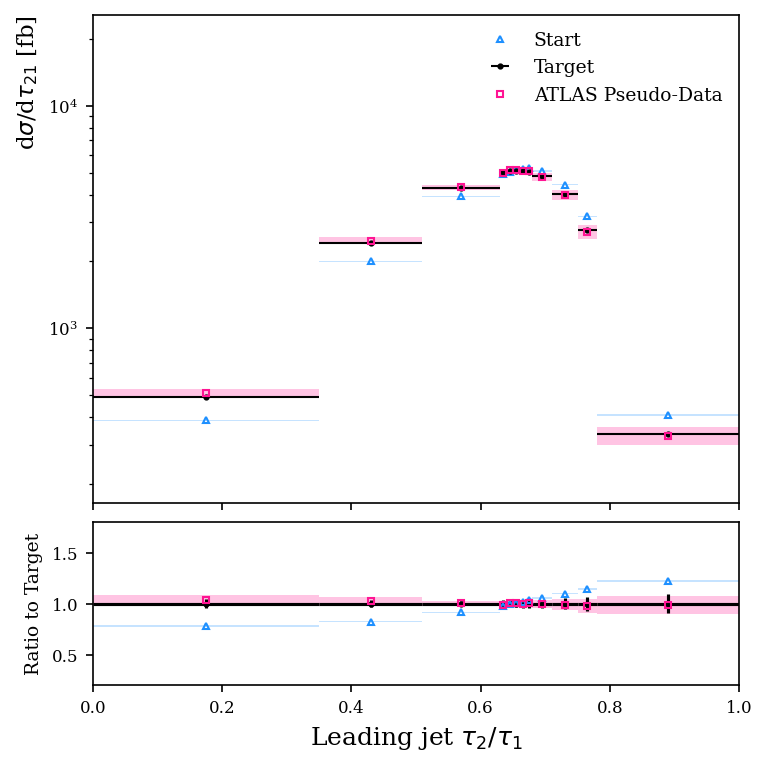

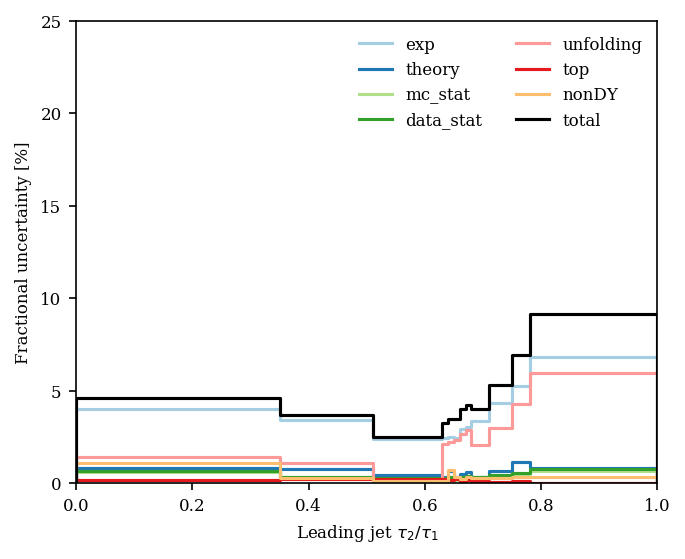

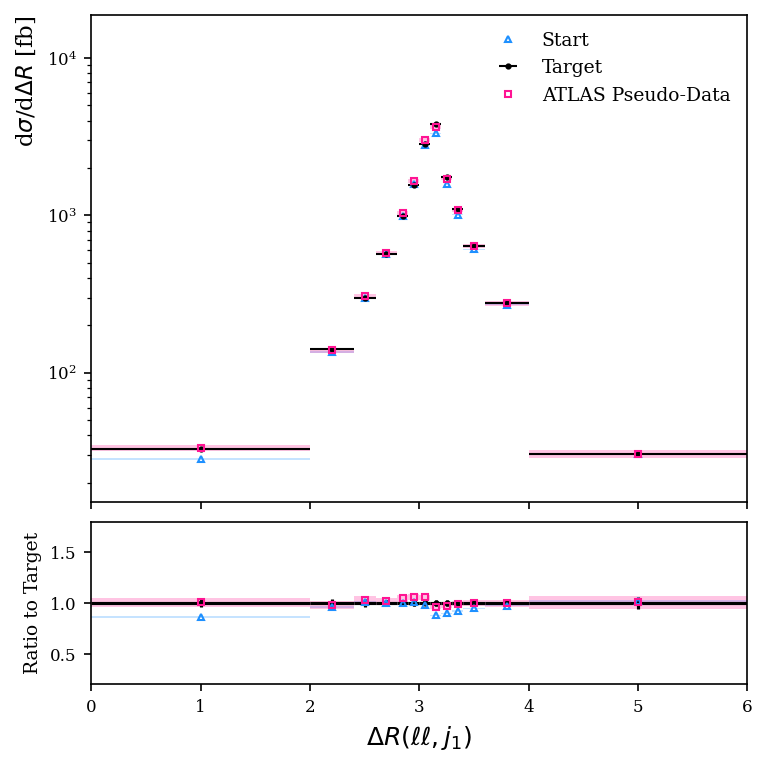

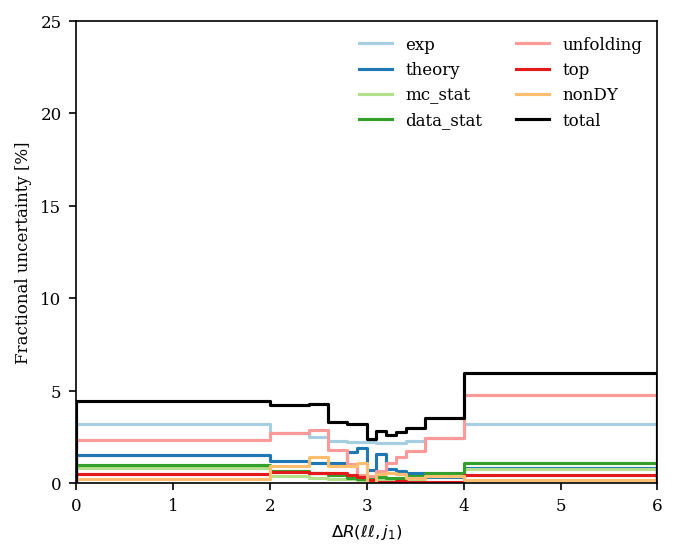

In [234]:
custom_binning("tau21", [0.0, 0.35, 0.51, 0.63, 0.71, 0.78, 1.0])
custom_binning("dR_ll", [0.0, 2.0, 2.4, 2.6, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.6, 4.0, 6.0])

In [206]:
#MC_PREDS TEST

mc_preds = np.load(r"C:\Users\HB\OneDrive\Desktop\OmniFold\files\pseudodata\mc_preds.npy", allow_pickle=True)

var = "pT_l1"  # change to whatever variable you're testing
bins = np.array([25.0, 125.0, 200.0, 300.0, 400.0, 500.0, 800.0])  # your custom bins

bin_widths = np.diff(bins)

# mc_preds counts and density
var_names = [list(bins_dict.items())[i][0] for i in range(len(mc_preds)) if i<=23]
var_idx = var_names.index(var)
mc_counts   = mc_preds[var_idx]['mgfxfx_counts']
mc_density  = mc_counts / lumi / np.diff(mc_preds[var_idx]['bins'])

# your counts and density
dy_counts, _ = np.histogram(df[var], bins=bins, weights=df.weight_mc)
your_density  = dy_counts / bin_widths

print(f"Variable: {var}")
print(f"\nmc_preds bins:    {mc_preds[var_idx]['bins']}")
print(f"your bins:        {bins}")
print(f"\nmc_preds counts:  {mc_counts}")
print(f"your counts:      {dy_counts}")
print(f"\nmc_preds density: {mc_density}")
print(f"your density:     {your_density}")
print(f"\nratio (your/mc):  {your_density / mc_density[:len(your_density)]}")

Variable: pT_l1

mc_preds bins:    [ 25. 125. 200. 300. 400. 500. 800.]
your bins:        [ 25. 125. 200. 300. 400. 500. 800.]

mc_preds counts:  [ 13800.65336185 139595.09788191  76472.71256791  14194.38717948
   3680.76923314   1754.41611064]
your counts:      [ 93.55756  959.76556  513.20764   93.84607   24.270752  11.733643]

mc_preds density: [ 0.99313856 13.39427153  5.50321766  1.02147288  0.26487977  0.04208444]
your density:     [ 0.93557564 12.79687419  5.13207642  0.93846069  0.24270752  0.03911214]

ratio (your/mc):  [0.94203939 0.95539904 0.93255923 0.91873285 0.91629317 0.929373  ]


In [ ]:
#DISREGARD FOR THE MOST PART

lumi = 138.96
var  = 'Ntracks_trackj1'
bins = np.array([0.5, 6.5, 10.5, 14.5, 19.5, 25.5, 39.5])
bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_widths  = np.diff(bins)

df        = multifold[mask_trackj1]
df_sherpa = multifold_sherpa[mask_sherpa_trackj1]
df_nonDY  = multifold_nonDY[mask_nonDY_trackj1]

# --- Start distribution (DY only) ---
dy_counts,    _ = np.histogram(df[var], bins=bins, weights=df.weight_mc)
dy_counts_sq, _ = np.histogram(df[var], bins=bins, weights=df.weight_mc**2)
start_density   = dy_counts / bin_widths
start_error_abs = start_density * np.sqrt(dy_counts_sq) / dy_counts  # absolute error

# --- Target distribution ---
target_counts,  _ = np.histogram(target[var], bins=bins, weights=target.weight_mc)
target_density     = target_counts / bin_widths

# --- Bin event count check ---
for i, count in enumerate(dy_counts):
    if count < 5000:
        print(f"Warning: bin {i+1} ({bins[i]:.1f}–{bins[i+1]:.1f}) has only {int(count)} events — statistical uncertainty may exceed 15%")

# --- Multifold (ATLAS Pseudo-Data) distribution ---
multifold_counts,  _ = np.histogram(df[var], bins=bins, weights=df.weights_nominal)
multifold_density     = multifold_counts / bin_widths

# --- Uncertainties ---
nom, _ = np.histogram(df[var], bins=bins, weights=df.weights_nominal)
final_event     = calculate_uncertainty(df, var, bins, event_systs)
final_theory    = calculate_uncertainty(df, var, bins, theory_systs)
final_track     = calculate_uncertainty(df, var, bins, track_systs)
final_muon      = calculate_uncertainty(df, var, bins, muon_systs)
final_mc_stat   = calculate_stat_uncertainty(df, var, bins, mc_stat_systs)
final_data_stat = calculate_stat_uncertainty(df, var, bins, data_stat_systs)
final_nn_init   = calculate_stat_uncertainty(df, var, bins, ensemble_systs) / np.sqrt(len(ensemble_systs))

syst, _      = np.histogram(df[var], bins=bins, weights=df.weights_dd)
target_dd, _ = np.histogram(df[var], bins=bins, weights=df.target_dd)
final_unfolding_dd = 100 * np.sqrt((syst - target_dd)**2) / target_dd

syst, _  = np.histogram(df_sherpa[var], bins=bins, weights=df_sherpa.weights_nominal)
smoothed = smooth_uncertainty(syst - nom, bin_centers)
final_unfolding_hv = 100 * np.sqrt(smoothed**2) / nom
final_unfolding    = np.sqrt(final_unfolding_hv**2 + final_unfolding_dd**2)

syst, _ = np.histogram(df[var], bins=bins, weights=df.weights_lumi)
final_lumi = 100 * np.sqrt((syst - nom)**2) / nom
syst, _ = np.histogram(df[var], bins=bins, weights=df.weights_topBackground)
final_top = 100 * np.sqrt((syst - nom)**2) / nom
syst, _ = np.histogram(df_nonDY[var], bins=bins, weights=df_nonDY.weights_nominal)
final_nonDY_unc = 100 * np.sqrt((syst - nom)**2) / nom

final_exp = np.sqrt(final_lumi**2 + final_muon**2 + final_track**2 + final_event**2)
total_unc = np.sqrt(final_theory**2 + final_exp**2 + final_mc_stat**2 +
                    final_data_stat**2 + final_unfolding**2 + final_top**2 + final_nonDY_unc**2)

# --- Plot ---
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(5, 5), dpi=150,
                        gridspec_kw={'height_ratios': [3, 1]}, constrained_layout=True)

# Main panel
_ = make_error_boxes(axs[0], bin_centers, start_density,
                     np.vstack([bin_widths/2, bin_widths/2]),
                     np.vstack([start_error_abs, start_error_abs]),
                     facecolor='dodgerblue', alpha=0.25, marker="^", label='Start')

axs[0].errorbar(bin_centers, target_density, xerr=bin_widths/2, yerr=None,
                marker=".", linestyle="None", color="k", alpha=1,
                ecolor="k", label="Target", markersize=4, linewidth=1)

_ = make_error_boxes(axs[0], bin_centers, multifold_density,
                     np.vstack([bin_widths/2, bin_widths/2]),
                     np.vstack([multifold_density*total_unc/100, multifold_density*total_unc/100]),
                     facecolor='deeppink', alpha=0.25, marker="s", label='ATLAS Pseudo-Data')

axs[0].set_yscale('log')
axs[0].set_ylabel(labels[var], fontsize=11, loc='top')
axs[0].legend(fontsize=9, frameon=False)

# Ratio panel
axs[1].errorbar(bin_centers, np.ones(len(bin_centers)), xerr=bin_widths/2,
                yerr=total_unc/100, marker=".", linestyle="None", color="k", markersize=4)

_ = make_error_boxes(axs[1], bin_centers, start_density/target_density,
                     np.vstack([bin_widths/2, bin_widths/2]),
                     np.vstack([start_error_abs/target_density]*2),
                     facecolor='dodgerblue', alpha=0.25, marker="^", label='Start')

_ = make_error_boxes(axs[1], bin_centers, multifold_density/target_density,
                     np.vstack([bin_widths/2, bin_widths/2]),
                     np.vstack([multifold_density/target_density*total_unc/100]*2),
                     facecolor='deeppink', alpha=0.25, marker="s", label='ATLAS Pseudo-Data')

axs[1].axhline(1, color='k', linewidth=0.8, linestyle='--')
axs[1].set_xlim(bins[0], bins[-1])
axs[1].set_ylim([0.2, 1.8])
axs[1].set_ylabel('Ratio to Target', fontsize=9)
axs[1].set_xlabel(plot_labels[var], fontsize=12)
plt.show()